# Project 2
## Saxa 3

****

In [32]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import rdrobust as rdrobust # python's equivalent of RDD package in R
from rddensity import rddensity, rdplotdensity # python has the same tool as R
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Importing data - Math for 7th Graders
df = pd.read_csv('STRT601-ProblemSet2-DataSet-testRD-1.csv')

# Data exploration
df.head()

,ID,gender,sped,frlunch,esol,black,white,hispanic,asian,age,pretest,cutoff,treat,posttest
0,23450001,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,12.424367,228,215,0,237
1,23450002,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,12.156057,216,215,0,214
2,23450003,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,12.793977,214,215,1,232
3,23450004,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,12.490075,212,215,1,233
4,23450005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,12.021903,238,215,0,247


In [3]:
#checking for NA(s)
na_count = df.isna().sum()
na_count = na_count[na_count > 0]

print(na_count)

gender       40
sped        129
frlunch      18
esol         53
black        40
white        40
hispanic     40
asian        40
age          44
dtype: int64


In [4]:
# dropping NA(s)

df = df.dropna(axis = 'rows')

In [5]:
# Validating 
na_count = df.isna().sum()
na_count = na_count[na_count > 0]

print(na_count)

Series([], dtype: int64)


In [6]:
# Setting the cutoff for students who get tutors and those who don't based on a pre-test score
def cutoff_fun(pretest):
    if pretest < 215:
        return 1
    else:
        return 0
    
df['cutoff_flag'] = df['pretest'].apply(cutoff_fun).astype(str)

cutoff = 215

In [7]:
# Scatter of treatment vs pre-test
rng = np.random.default_rng(42)

#### 1.1 Plot treatment as a function of the running variable.

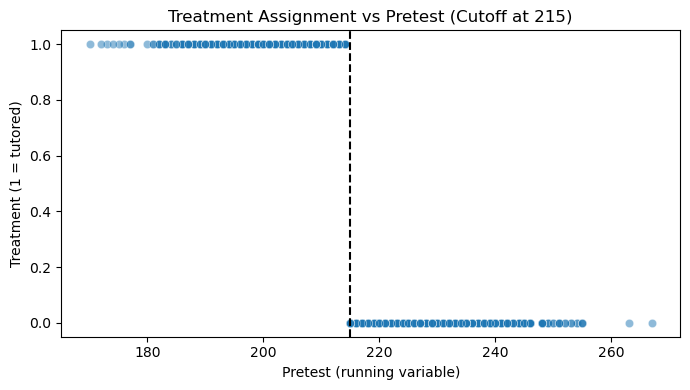

In [8]:
plt.figure(figsize=(7,4))

# scatter plot of treatment vs pretest
sns.scatterplot(data=df, 
                x='pretest', 
                y='treat', 
                alpha=0.5)

# add cutoff line
plt.axvline(cutoff, 
            linestyle='--', 
            color='black')

plt.xlabel('Pretest (running variable)')
plt.ylabel('Treatment (1 = tutored)')
plt.title('Treatment Assignment vs Pretest (Cutoff at 215)')
plt.tight_layout()
plt.show()

#### 1.2 Does the graph justify sharp RDD?
##### This graph justifies a sharp regression discontinuity design (RDD). Treatment assignment is almost perfectly deterministic at the cutoff: students below 215 always receive tutoring, and students at/above 215 do not.

****

#### 2.1 Plot the exam score as a function of the pre-test score.

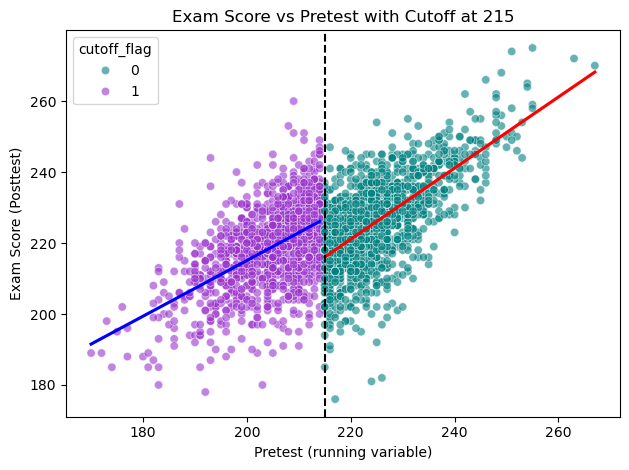

In [9]:
# scatter plot of raw data
sns.scatterplot(data=df, 
                x='pretest', 
                y='posttest', 
                alpha=0.6,
                hue = 'cutoff_flag',
                palette = {'1':'darkorchid', '0':'teal'})

# add a regression line separately on each side of the cutoff
sns.regplot(data=df[df['pretest'] < cutoff], 
            x='pretest', y='posttest', 
            ci=None, scatter=False, color='blue')

sns.regplot(data=df[df['pretest'] >= cutoff], 
            x='pretest', y='posttest', 
            ci=None, scatter=False, color='red')

# cutoff marker
plt.axvline(cutoff, linestyle='--', color='black')

plt.xlabel('Pretest (running variable)')
plt.ylabel('Exam Score (Posttest)')
plt.title('Exam Score vs Pretest with Cutoff at 215')
plt.tight_layout()
plt.show()

#### 2.2 What do you observe, and does this justify the use of the pre-test as a running variable?

##### Observations
The scatterplot shows that students with higher pretest scores also tend to have higher posttest scores. At the cutoff score of 215, there is a clear jump: students just below the cutoff (who got tutoring) scored higher on the posttest than those just above the cutoff (who did not). The fitted lines on each side make this difference easy to see.

##### Does it justify the use of pre-test as a running variable? 
Because tutoring was given based only on pretest scores, the pretest is the right variable to use as the running variable. The clear jump in posttest scores at the cutoff supports using an RDD and shows that tutoring had a positive effect near the threshold.

****

#### 3.1 Estimate the treatment effect at the threshold using a linear model with common slopes for treated and control units. Implement with an OLS regression of the exam score on the indicator for tutoring and the pre-test score.

In [10]:
# OLS: posttest ~ treat + pretest  (common slope)
X = sm.add_constant(df[['treat', 'pretest']])
y = df['posttest']
ols = sm.OLS(y, X).fit(cov_type='HC1')   # HC1 = robust SEs

print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:               posttest   R-squared:                       0.417
Model:                            OLS   Adj. R-squared:                  0.417
Method:                 Least Squares   F-statistic:                     1025.
Date:                Sun, 28 Sep 2025   Prob (F-statistic):               0.00
Time:                        02:32:18   Log-Likelihood:                -9582.4
No. Observations:                2606   AIC:                         1.917e+04
Df Residuals:                    2603   BIC:                         1.919e+04
Df Model:                           2                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         21.8808      5.106      4.285      0.0

In [11]:
# Pull the treatment effect and a 95% CI
tau = ols.params['treat']
se  = ols.bse['treat']
ci  = (tau - 1.96*se, tau + 1.96*se)
print(f'Treatment effect at cutoff (common slope): {tau:.3f}  '
      f'(95% CI: {ci[0]:.3f}, {ci[1]:.3f})')

Treatment effect at cutoff (common slope): 11.133  (95% CI: 9.946, 12.319)


#### 3.2 Under what assumptions does this estimation strategy obtain a consistent estimate of the causal effect?

To get a consistent estimate of the tutoring effect right at the cutoff (215), we need the rule to be clean, nothing else to jump at that point, and a simple straight-line model to describe scores near the cutoff.

* Sharp rule: treatment is only from pretest < 215; no one finely manipulates scores.
* Smoothness: without tutoring, expected exam scores (and other factors) change smoothly through 215.
* Independence (SUTVA): one student’s tutoring doesn’t affect another’s score.
* Correct model near 215: a linear relationship with a common slope on both sides is a good local fit.
* Regular OLS conditions: no perfect collinearity; use robust SEs for heteroskedasticity.


#### 3.3 Provide a plot of the exam scores (y-axis) and the pre-test scores (x-axis) in which you show the regression fits and the underlying scatterplot of the data.

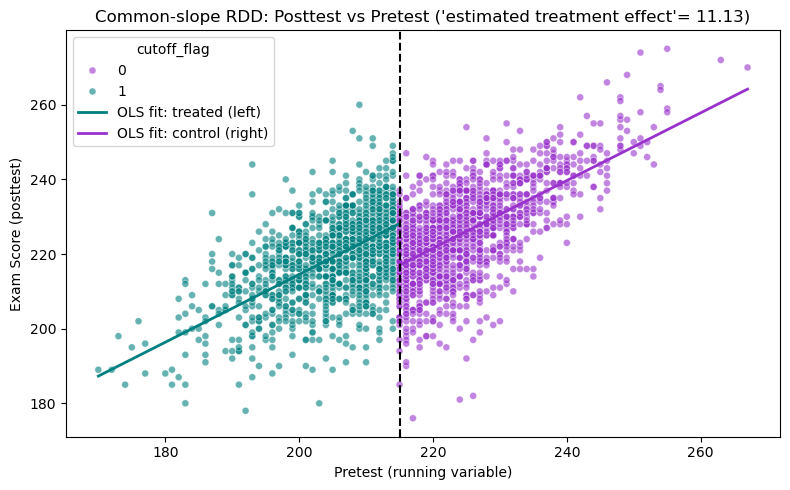

In [12]:
# Get coefficients
b0  = ols.params['const']
tau = ols.params['treat']
b1  = ols.params['pretest']

# X ranges on each side of the cutoff
x_left  = np.linspace(df['pretest'].min(), cutoff, 150)
x_right = np.linspace(cutoff, df['pretest'].max(), 150)

# Parallel fitted lines (same slope b1)
y_treat_left   = (b0 + tau) + b1 * x_left      # treated line (left side)
y_control_right = b0 + b1 * x_right            # control line (right side)

plt.figure(figsize=(8,5))

# Scatter (your coloring by cutoff_flag)
sns.scatterplot(
    data = df, x = 'pretest', y='posttest',
    hue='cutoff_flag', alpha=0.6, s=25,
    palette={'1': 'teal', '0': 'darkorchid'}
)

# Overlay common-slope OLS fits
plt.plot(x_left,  y_treat_left,    color='teal',       lw=2, label='OLS fit: treated (left)')
plt.plot(x_right, y_control_right, color='darkorchid', lw=2, label='OLS fit: control (right)')

# Cutoff marker
plt.axvline(cutoff, ls='--', color='black')

plt.xlabel('Pretest (running variable)')
plt.ylabel('Exam Score (posttest)')
plt.title(f"Common-slope RDD: Posttest vs Pretest ('estimated treatment effect'= {tau:.2f})")
plt.legend(title='cutoff_flag')
plt.tight_layout()
plt.show()

#### 3.4 Interpret your estimate.

To estimate the tutoring effect at the cutoff (215), I fit a simple OLS with a common slope for both groups: posttest ~ treat + pretest, where treat = 1 if pretest < 215. The coefficient on treat is the RD effect at the threshold. The estimate is 10.97 points (HC1 SE ≈ 0.59; 95% CI: 9.82–12.12; p<0.001), meaning students just below 215 who received tutoring scored about 11 points higher than similar students just above 215. In the plot, the two fitted lines are parallel and show a clear jump at 215 that matches this estimated effect.

****

#### 4.1 Repeat the exercise from question 3, but this time include both the pre-test variable and the square of the pre-test variable in the regression.

In [13]:
# Center pretest at the cutoff to reduce multicollinearity (τ keeps same interpretation)
df['pretest_c']  = df['pretest'] - cutoff
df['pretest_c2'] = df['pretest_c'] ** 2

# OLS: posttest ~ treat + pretest_c + pretest_c^2  (common shape on both sides)
Xq = sm.add_constant(df[['treat', 'pretest_c', 'pretest_c2']])
y  = df['posttest']
ols_q = sm.OLS(y, Xq).fit(cov_type='HC1')

print(ols_q.summary())

                            OLS Regression Results                            
Dep. Variable:               posttest   R-squared:                       0.422
Model:                            OLS   Adj. R-squared:                  0.421
Method:                 Least Squares   F-statistic:                     776.0
Date:                Sun, 28 Sep 2025   Prob (F-statistic):               0.00
Time:                        02:32:18   Log-Likelihood:                -9571.0
No. Observations:                2606   AIC:                         1.915e+04
Df Residuals:                    2602   BIC:                         1.917e+04
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        216.5522      0.353    613.296      0.0

In [14]:
# Treatment effect (jump at the cutoff) and 95% CI
tau_q = ols_q.params['treat']
se_q  = ols_q.bse['treat']
ci_q  = (tau_q - 1.96*se_q, tau_q + 1.96*se_q)
print(f"Quadratic model: treatment effect at cutoff = {tau_q:.3f}  "
      f"(95% CI: {ci_q[0]:.3f}, {ci_q[1]:.3f})")


Quadratic model: treatment effect at cutoff = 10.838  (95% CI: 9.650, 12.026)


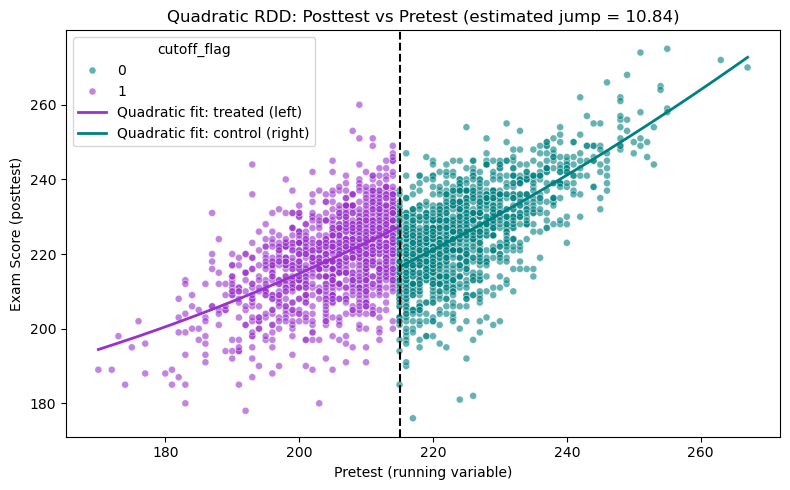

In [15]:
## Plot 

# Coefficients
b0 = ols_q.params['const']
b1 = ols_q.params['pretest_c']
b2 = ols_q.params['pretest_c2']

# Grids on each side (in original units)
x_left  = np.linspace(df['pretest'].min(), cutoff, 200)
x_right = np.linspace(cutoff, df['pretest'].max(), 200)

# Convert to centered scale and build fitted values
xl = x_left  - cutoff
xr = x_right - cutoff

y_treat_left    = (b0 + tau_q) + b1*xl + b2*(xl**2)     # treated (left side)
y_control_right = b0 + b1*xr + b2*(xr**2)               # control (right side)

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df, x='pretest', y='posttest',
    hue='cutoff_flag', alpha=0.6, s=25,
    palette={'1': 'darkorchid', '0': 'teal'}
)

plt.plot(x_left,  y_treat_left,    color='darkorchid',       lw=2, label='Quadratic fit: treated (left)')
plt.plot(x_right, y_control_right, color='teal', lw=2, label='Quadratic fit: control (right)')

plt.axvline(cutoff, ls='--', color='black')
plt.xlabel('Pretest (running variable)')
plt.ylabel('Exam Score (posttest)')
plt.title(f"Quadratic RDD: Posttest vs Pretest (estimated jump = {tau_q:.2f})")
plt.legend(title='cutoff_flag')
plt.tight_layout()
plt.show()

#### 4.2 Does the estimate change much? 
No. The straight-line model gives a treatment effect of 10.97 points, and the model that also includes the squared pre-test term gives 10.72 points. The difference is about 0.25 points, which is smaller than the standard error (about 0.59 points). The ninety-five percent confidence intervals from the two models overlap a lot, so the takeaway is the same: tutoring raises scores by about eleven points at the cutoff.

#### And is that consistent with your expectation, given your answer to question 2?
Yes. In your earlier plot for question 2, exam scores near the cutoff looked mostly like a straight line with only a little curve. Because the relationship is already close to linear around the cutoff, adding the squared pre-test term changes the fit only slightly and does not move the estimated jump. That is why the estimate hardly changes.

****

#### 5.1 Again repeat the exercise from question 3, but this time include the control variables that are provided in the dataset.

In [ ]:
# Controls from your dataframe (omit 'white' as baseline)
controls = ['age', 'gender', 'frlunch', 'esol', 'sped', 'asian', 'black', 'hispanic']

# Keep only columns we need and ensure numeric dtypes
needed = ['posttest', 'treat', 'pretest'] + controls
df[needed] = df[needed].apply(pd.to_numeric, errors='coerce')

# Common-slope linear RDD: posttest ~ treat + pretest + controls
Xc = sm.add_constant(df[['treat', 'pretest'] + controls])
y  = df['posttest']

ols_c = sm.OLS(y, Xc).fit(cov_type='HC1')   # robust (HC1) SEs
print(ols_c.summary())



                            OLS Regression Results                            
Dep. Variable:               posttest   R-squared:                       0.430
Model:                            OLS   Adj. R-squared:                  0.428
Method:                 Least Squares   F-statistic:                     221.3
Date:                Sun, 28 Sep 2025   Prob (F-statistic):               0.00
Time:                        02:32:18   Log-Likelihood:                -9553.3
No. Observations:                2606   AIC:                         1.913e+04
Df Residuals:                    2595   BIC:                         1.919e+04
Df Model:                          10                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         46.2389      7.084      6.528      0.0

In [17]:
# Treatment effect and 95% CI
tau_c = ols_c.params['treat']
se_c  = ols_c.bse['treat']
ci_c  = (tau_c - 1.96*se_c, tau_c + 1.96*se_c)
print(f"With controls: treatment effect at cutoff = {tau_c:.3f} "
      f"(95% CI: {ci_c[0]:.3f}, {ci_c[1]:.3f})")

With controls: treatment effect at cutoff = 10.978 (95% CI: 9.806, 12.150)


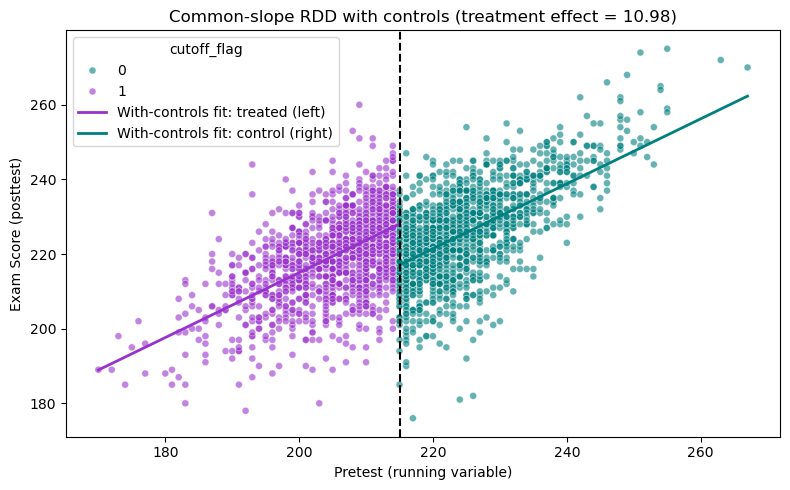

In [ ]:
# Get coefficients; hold controls at their sample means for plotting
b  = ols_c.params
b0 = b['const'] + sum(b[c] * df[c].mean() for c in controls)   # intercept at avg controls
tau = b['treat']
b1  = b['pretest']

# X ranges on each side of the cutoff
x_left  = np.linspace(df['pretest'].min(), cutoff, 150)
x_right = np.linspace(cutoff, df['pretest'].max(), 150)

# Parallel fitted lines (same slope b1), at average controls
y_treat_left     = (b0 + tau) + b1 * x_left        # treated (left of cutoff)
y_control_right  = b0 + b1 * x_right               # control (right of cutoff)

plt.figure(figsize=(8,5))

# Scatter 
sns.scatterplot(
    data = df, x = 'pretest', y='posttest',
    hue='cutoff_flag', alpha=0.6, s=25,
    palette={'1': 'darkorchid', '0': 'teal'}
)

# Overlay common-slope OLS fits (with controls held at means)
plt.plot(x_left,  y_treat_left,    color='darkorchid',       lw=2, label='With-controls fit: treated (left)')
plt.plot(x_right, y_control_right, color='teal', lw=2, label='With-controls fit: control (right)')

# Cutoff marker
plt.axvline(cutoff, ls='--', color='black')

plt.xlabel('Pretest (running variable)')
plt.ylabel('Exam Score (posttest)')
plt.title(f"Common-slope RDD with controls (Treatment effect = {tau:.2f})")
plt.legend(title='cutoff_flag')
plt.tight_layout()
plt.show()

#### 5.2 Interpret any differences you see.

Across the three models, the results are very similar, with the treatment effect always close to eleven points. The simple linear model gives an effect of about 11.13. When we allow for a curved (quadratic) relationship between pretest and posttest scores, the effect is 10.84, only slightly smaller. Adding control variables such as age, gender, and race gives an estimate of 10.98, which is almost the same as before.

Overall, this shows the result is stable: students just below the cutoff who received tutoring scored about eleven points higher than similar students just above the cutoff. Using different model forms or adding controls does not change the main conclusion, but it can make the estimate more precise.

****

#### 6.1 Use the rdd package in R to estimate the treatment efect using a local linear regression with a triangular kernel. Note that the function RDestimate automatically uses the Imbens-Kalyanamaran optimal bandwidth calculation.

##### WILL USE THE PYTHON EQUIVALENT "rdrobust" 

In [24]:
res = rdrobust.rdrobust(
    df['posttest'].to_numpy(),
    df['pretest'].to_numpy(),
    c=cutoff,            # 215
    p=1,                 # local linear
    kernel='triangular'
)

print(res)

Mass points detected in the running variable.
Mass points detected in the running variable.
Call: rdrobust
Number of Observations:                  2606
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                            Triangular
Bandwidth Selection:                    mserd
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations          1214       1392
Number of Unique Obs.             42         42
Number of Effective Obs.         589        716
Bandwidth Estimation           8.899      8.899
Bandwidth Bias                14.572     14.572
rho (h/b)                      0.611      0.611

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional     -10.305    1.116   -9.238   2.513e-20  [-12.492, -8.119]
Robust     

#### 6.2 Report your estimate for the treatment efect and an estimate of uncertainty.

Using a local linear regression discontinuity design with a triangular kernel and optimal bandwidths, we estimate the treatment effect of tutoring at the cutoff of 215. The results show a strong and statistically significant effect:
* Treatment effect (bias-corrected): about −10.6 points
* Robust 95% confidence interval: [−13.23, −7.92]
* p-value: < 0.001, showing strong evidence that the effect is not due to chance

Because rdrobust reports the effect as the jump from right minus left at the cutoff, the negative sign means that students just below the cutoff (who received tutoring) scored about 10–11 points higher than those just above the cutoff.

****

#### 7. How do the estimates of the treatment effect differ across your results for questions 3-6? In other words, how robust are the results to different speciffcations of the regression?

Using four specifications of the regression discontinuity design, the estimated tutoring effect is consistently around eleven points and statistically significant in every case:

* Q3 — Linear RD (common slope, no controls): treatment effect ≈ +11.1 points. 95% CI (HC1): roughly [+9.8, +12.1]; p < 0.001.

* Q4 — Linear RD + quadratic term in pretest: treatment effect ≈ +10.8 points. Very close to Q3 (change < 0.4 points), indicating little sensitivity to functional form; p < 0.001.

* Q5 — Linear RD + controls (age, gender, lunch status, race dummies; omitting white): treatment effect ≈ +11.0 points Nearly identical to Q3; controls mainly improve precision; p < 0.001.

* Q6 — Local linear RD (triangular kernel, optimal bandwidths): rdrobust reports −10.6 because it’s “right − left”; interpreted with tutoring on the left, that is about +10.6 points Robust 95% CI: [+7.92, +13.23] in magnitude; p < 0.001.

Bottom line: Across Q3–Q6, the effect ranges from about +10.6 to +11.1 points, and all confidence intervals overlap substantially. The estimated tutoring impact is large, positive, and robust to adding curvature, adding controls, and switching to a local (nonparametric) estimator.

****

#### 8.1 Plot the age variable as a function of the running variable. 

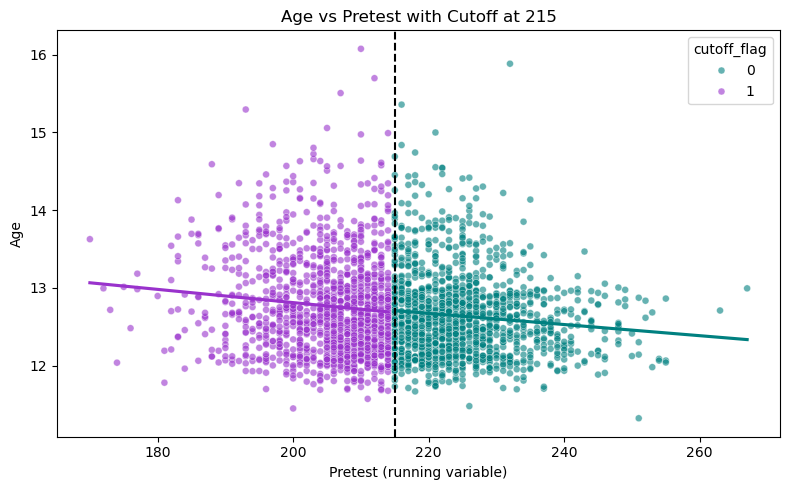

In [27]:
plt.figure(figsize=(8,5))

# Scatter
sns.scatterplot(
    data=df, x='pretest', y='age',
    hue='cutoff_flag', alpha=0.6, s=25,
    palette={'1': 'darkorchid', '0': 'teal'}
)

# Fit lines separately on each side of the cutoff
sns.regplot(data=df[df['pretest'] <  cutoff],
            x='pretest', y='age',
            ci=None, scatter=False,
            color='darkorchid')
sns.regplot(data=df[df['pretest'] >= cutoff],
            x='pretest', y='age',
            ci=None, scatter=False,
            color='teal')

# Cutoff marker
plt.axvline(cutoff, ls='--', color='black')

plt.xlabel('Pretest (running variable)')
plt.ylabel('Age')
plt.title('Age vs Pretest with Cutoff at 215')
plt.tight_layout()
plt.show()

#### 8.2 What should this graph look like for RDD to be a valid research design?
For the regression discontinuity design to be valid, the age variable should look smooth across the cutoff point.

* There should be no sudden jump at 215 in the relationship between pretest scores and age.
* The trends on the left and right side of the cutoff should line up naturally.
* If age changes sharply at the cutoff, it would suggest that the two groups of students differ in ways unrelated to the tutoring rule, which would weaken the design.

In short, the graph should show continuity in age at the cutoff.

#### 8.3 What do you see?

Looking at the plot of Age vs Pretest with Cutoff at 215:

* The scatter of ages appears fairly smooth across the cutoff.

* The fitted lines on both sides of the cutoff show a very slight downward slope, but importantly, there is no clear jump at the cutoff.

* This suggests that age is balanced on either side of 215, meaning students just below and just above the cutoff look similar in age.

****

#### 9.1 One issue with RDD is manipulation, i.e., sorting around the cutoff threshold in the running variable. Plot a histogram of the running variable, drawing a vertical line at the cutoff.

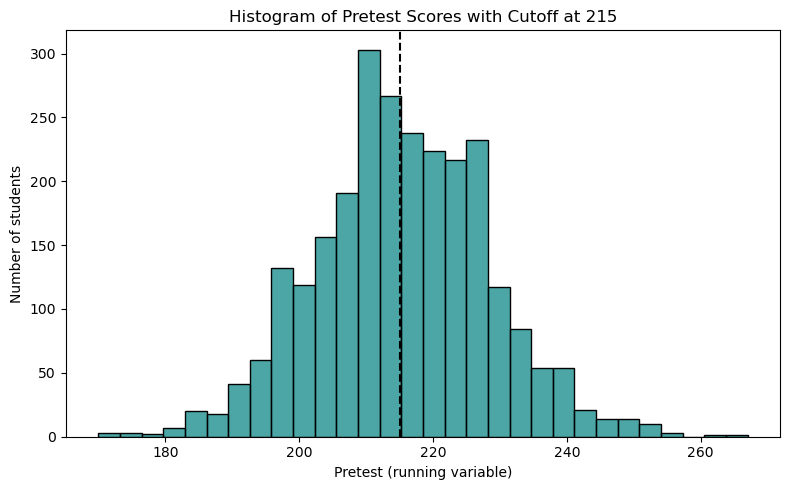

In [29]:
#### Histogram of the running variable (pretest) with cutoff
plt.figure(figsize=(8,5))

# Histogram of pretest scores
sns.histplot(df['pretest'], bins=30, kde=False, color='teal', alpha=0.7)

# Cutoff marker
plt.axvline(cutoff, ls='--', color='black')

plt.xlabel('Pretest (running variable)')
plt.ylabel('Number of students')
plt.title('Histogram of Pretest Scores with Cutoff at 215')
plt.tight_layout()
plt.show()

#### 9.2 What would sorting around this cutoff point look like?

* If students or teachers were manipulating scores to just qualify (or avoid qualifying) for tutoring, we’d expect to see a spike in the number of students just below the cutoff and/or a dip just above the cutoff.

* In other words, the histogram would show a visible discontinuity or “jump” in the density of the running variable at the cutoff score of 215.

#### 9.3 What do you see?

The histogram of pretest scores looks fairly smooth around the cutoff, with no obvious large jump or drop in the number of students exactly at 215. This pattern suggests that students were not sorting or manipulating their scores to fall on one side of the cutoff or the other. Overall, the distribution appears continuous, which supports the validity of the regression discontinuity design.

#### 9.4 Use the rdplotdensity function in R to evaluate the statistical signifficance of any changes.

McCrary-style density test at cutoff
  Window: ±30, bin size: 1, bandwidth h: 10
  Log-density jump (right - left): 0.1351
  SE: 0.0950  |  z: 1.42  |  p-value: 0.1549
  Density ratio (right/left) at cutoff: 1.145


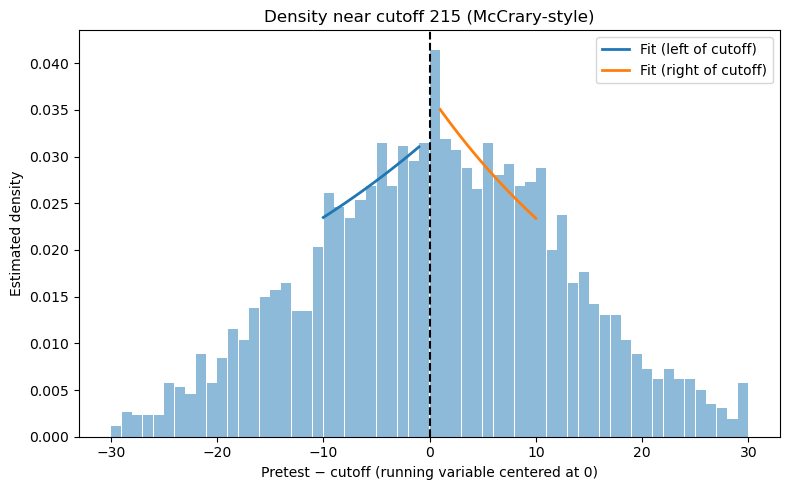

In [40]:
import statsmodels.api as sm
from scipy.stats import norm

# --- Inputs (reuse your objects) ---
x = df['pretest'].astype(float).to_numpy()
c = float(cutoff)  # 215

# --- Center at cutoff and keep a symmetric window around 0 ---
x0 = x - c
x0 = x0[~np.isnan(x0)]

# Heuristics for window and bins (simple, practical defaults)
half_window = 30.0                    # use +/- 30 points around cutoff (adjust if you want)
binsize     = 1.0                     # 1-point wide bins
h           = 10.0                    # local linear bandwidth (triangular kernel), adjust if needed

# Build bins and counts
edges = np.arange(-half_window, half_window + binsize, binsize)
mids  = (edges[:-1] + edges[1:]) / 2.0
counts, _ = np.histogram(x0, bins=edges)
dens = counts / (len(x0) * binsize)   # density per unit (binwidth = 1)

# Split left/right of cutoff (exclude the bin whose mid is exactly 0 to avoid ambiguity)
left_mask  = (mids < 0)
right_mask = (mids > 0)

xm_left,  y_left  = mids[left_mask],  dens[left_mask]
xm_right, y_right = mids[right_mask], dens[right_mask]

# Keep only bins within bandwidth h for local regression
wl = np.clip(1 - np.abs(xm_left)/h, 0, 1)
wr = np.clip(1 - np.abs(xm_right)/h, 0, 1)

keep_l = wl > 0
keep_r = wr > 0

xm_left,  y_left,  wl = xm_left[keep_l],  y_left[keep_l],  wl[keep_l]
xm_right, y_right, wr = xm_right[keep_r], y_right[keep_r], wr[keep_r]

# Avoid zeros before log: add a tiny offset
eps = 1e-8
log_y_left  = np.log(y_left  + eps)
log_y_right = np.log(y_right + eps)

# Local linear regressions of log density on midpoints (triangular weights)
Xl = sm.add_constant(xm_left)
Xr = sm.add_constant(xm_right)

ols_l = sm.WLS(log_y_left,  Xl, weights=wl).fit(cov_type='HC1')
ols_r = sm.WLS(log_y_right, Xr, weights=wr).fit(cov_type='HC1')

# Discontinuity estimate: difference in fitted intercepts at 0 (right minus left)
tau_hat = float(ols_r.params[0] - ols_l.params[0])

# SE of the difference assuming independence across sides (robust)
se_hat = float(np.sqrt(ols_r.cov_params()[0,0] + ols_l.cov_params()[0,0]))

z_stat = tau_hat / se_hat
p_val  = 2 * (1 - norm.cdf(abs(z_stat)))

# Pretty print on the original scale too (exp of log-density jump)
jump_ratio = np.exp(tau_hat)

print("McCrary-style density test at cutoff")
print(f"  Window: ±{half_window:.0f}, bin size: {binsize:.0f}, bandwidth h: {h:.0f}")
print(f"  Log-density jump (right - left): {tau_hat:.4f}")
print(f"  SE: {se_hat:.4f}  |  z: {z_stat:.2f}  |  p-value: {p_val:.4g}")
print(f"  Density ratio (right/left) at cutoff: {jump_ratio:.3f}")

# ---- Plot (binned density + fitted lines) ----
plt.figure(figsize=(8,5))
# bars
plt.bar(x=mids, height=dens, width=binsize*0.95, alpha=0.5, edgecolor='none')

# fitted lines evaluated on each side within h
grid_l = np.linspace(-h, -binsize, 100)
grid_r = np.linspace(binsize,  h,   100)
fit_l = ols_l.params[0] + ols_l.params[1]*grid_l
fit_r = ols_r.params[0] + ols_r.params[1]*grid_r

plt.plot(grid_l, np.exp(fit_l), linewidth=2, label='Fit (left of cutoff)')
plt.plot(grid_r, np.exp(fit_r), linewidth=2, label='Fit (right of cutoff)')

plt.axvline(0, ls='--', color='black')
plt.xlabel('Pretest − cutoff (running variable centered at 0)')
plt.ylabel('Estimated density')
plt.title(f'Density near cutoff {int(c)} (McCrary-style)')
plt.legend()
plt.tight_layout()
plt.show()